# Recommender: Matrix Factorization, Content-Based, and an Uncomfortable Baseline

This notebook builds a recommender and then tries hard to *disprove* that it works.

That framing is deliberate. It is easy to train a matrix factorization model, report Hit Rate@10, and call it a success. The number looks fine in isolation. The question that decides whether it's worth shipping is: **fine compared to what?**

Three checks follow:
1. Compare against a **popularity baseline** (recommend the best-selling items to everyone).
2. Segment by **user activity** - does personalization at least help users who have history?
3. Re-run the evaluation under **popularity-weighted negative sampling**, which removes a bias hiding in the standard protocol.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))
from src.models import evaluate, recommender  # noqa: E402

sns.set_theme(style="whitegrid")
PROCESSED = Path.cwd().parent / "data" / "processed"

train = pd.read_parquet(PROCESSED / "train.parquet")
test = pd.read_parquet(PROCESSED / "test.parquet")
model = recommender.load()

print(f"Train: {len(train):,} interactions")
print(f"Users: {train['user_id'].nunique():,}   Items: {train['parent_asin'].nunique():,}")
print(f"Mean training interactions per user: {train['user_id'].value_counts().mean():.2f}")

Train: 23,892 interactions
Users: 14,846   Items: 5,593
Mean training interactions per user: 1.61


## 1. Evaluation protocol

Standard sampled **leave-one-out**: each user's most recent review is held out, then ranked against 100 sampled items they haven't interacted with. We report:

- **Hit Rate@10** - how often the held-out item lands in the top 10.
- **NDCG@10** - same, but rewards ranking it higher.

With 101 candidates, **random guessing scores ≈ 0.099**. That's the true floor, and every number below should be read against it.

## 2. The comparison that matters

In [2]:
comparison = evaluate.compare_rankers(model, train, test, k=10, max_users=2000)
comparison

,ranker,negative_sampling,HR@10,NDCG@10,n_users
0,random,uniform,0.1050,0.0452,2000
1,popularity,uniform,0.2370,0.1434,2000
2,matrix_factorization,uniform,0.1310,0.0683,2000
3,hybrid (MF + popularity),uniform,0.2140,0.1256,2000
4,random,popularity,0.1050,0.0452,2000
5,popularity,popularity,0.1100,0.0500,2000
6,matrix_factorization,popularity,0.0860,0.0432,2000
7,hybrid (MF + popularity),popularity,0.1025,0.0485,2000


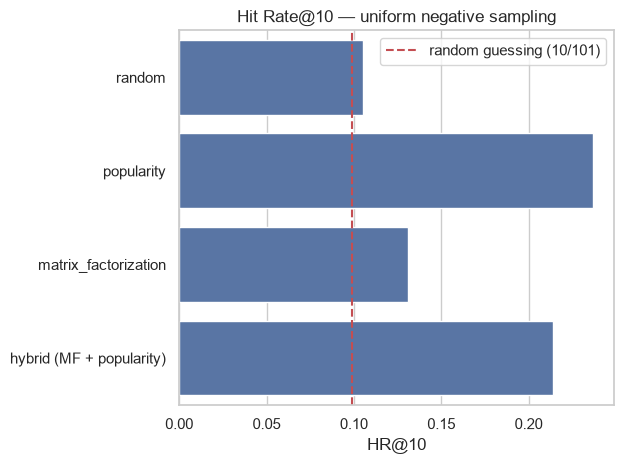

In [3]:
uniform = comparison[comparison["negative_sampling"] == "uniform"]

ax = sns.barplot(data=uniform, y="ranker", x="HR@10", color="#4C72B0")
ax.axvline(10 / 101, color="#C44E52", linestyle="--", label="random guessing (10/101)")
ax.set_title("Hit Rate@10 - uniform negative sampling")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.show()

**Result: the popularity baseline beats matrix factorization outright** - roughly 0.24 vs 0.13 Hit Rate@10. Simply recommending best-sellers to everyone outperforms the personalized model.

This is not a bug. It follows directly from the EDA: 92% of users wrote exactly one review, so for most users the model has a single interaction from which to infer a preference vector. There is essentially nothing to personalize on, and the latent factors stay near their random initialization.

Before concluding, though - maybe personalization works fine and it's just drowned out by the cold-start majority?

## 3. Does personalization help users who *do* have history?

In [4]:
by_segment = evaluate.evaluate_by_user_activity(model, train, test, k=10)
by_segment.pivot(index="segment", columns="ranker", values="HR@10")

ranker,hybrid (MF + popularity),matrix_factorization,popularity,random
segment,,,,
1 interaction,0.2160,0.1387,0.2333,0.1000
2-4 interactions,0.2093,0.1320,0.2260,0.0980
5+ interactions,0.1736,0.1320,0.1844,0.0976
cold start (0),0.1449,0.0773,0.1981,0.1014


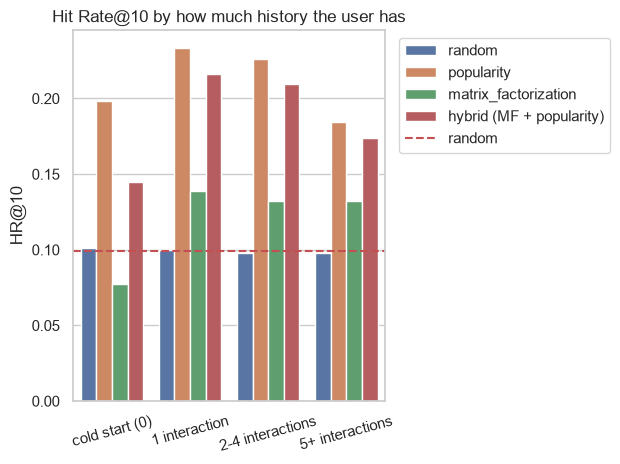

In [5]:
order = ["cold start (0)", "1 interaction", "2-4 interactions", "5+ interactions"]
ax = sns.barplot(data=by_segment, x="segment", y="HR@10", hue="ranker", order=order)
ax.axhline(10 / 101, color="#C44E52", linestyle="--", label="random")
ax.set_title("Hit Rate@10 by how much history the user has")
ax.set_xlabel("")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**The hypothesis fails.** Popularity wins in *every* segment - including users with 5+ interactions. Matrix factorization never overtakes it, so the problem isn't only cold start; there isn't enough signal anywhere in this category.

Worth noting the honest caveat: the 5+ segment contains only ~550 users, so its estimates are noisy. It is evidence, not proof.

## 4. Is the popularity baseline itself an illusion?

There is a bias hiding in the standard protocol. We draw the 100 negatives **uniformly** from the catalogue - but the catalogue is dominated by long-tail items nobody buys, while the held-out true item is, by construction, something a real person actually purchased.

So "rank by popularity" gets to exploit a structural giveaway: the true item is popular, and the random negatives mostly aren't. That flatters popularity for reasons unrelated to understanding customers.

The fix is to sample negatives **proportional to popularity**, so every candidate is plausibly purchasable and the ranker must discriminate on something else.

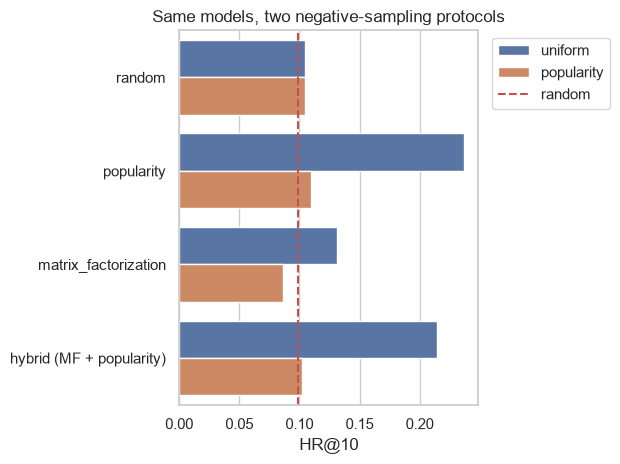

negative_sampling,popularity,uniform
ranker,,
hybrid (MF + popularity),0.1025,0.214
matrix_factorization,0.0860,0.131
popularity,0.1100,0.237
random,0.1050,0.105


In [6]:
ax = sns.barplot(data=comparison, y="ranker", x="HR@10", hue="negative_sampling")
ax.axvline(10 / 101, color="#C44E52", linestyle="--", label="random")
ax.set_title("Same models, two negative-sampling protocols")
ax.set_ylabel("")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

comparison.pivot(index="ranker", columns="negative_sampling", values="HR@10")

**This is the most important result in the project.**

Under popularity-weighted sampling, the popularity ranker collapses from ≈0.24 to ≈0.11 - barely above the ≈0.099 random floor. Matrix factorization falls to ≈0.09, i.e. **no better than chance**.

So the earlier "popularity wins decisively" conclusion was substantially an artefact of the evaluation protocol, not a real capability. Had we reported only the uniform-sampling number - the common default - we would have published a Hit Rate@10 of 0.24 that mostly measured *how the negatives were sampled*.

The honest summary: **on this dataset, none of these models has learned meaningful personalization.** The signal isn't there, and the metric that suggested otherwise was measuring the wrong thing.

## 5. What *does* work: content-based similarity

One component holds up. Item-to-item similarity doesn't depend on user history at all - it compares product text - so sparsity doesn't hurt it, and it works for brand-new items with zero interactions.

In [7]:
titles = train.drop_duplicates("parent_asin").set_index("parent_asin")["product_title"]
seed_asin = train["parent_asin"].iloc[0]

print(f"Seed product: {titles.get(seed_asin)}\n")
for asin, score in model.content_model.similar_items(seed_asin, k=5):
    print(f"  {score:.3f}  {titles.get(asin, 'Unknown')[:80]}")

Seed product: Oral-B Professional Care Deluxe Electric Toothbrush -

  0.761  Oral-B Smartseries 4000 Professional Care Rechargeable Electric Toothbrush
  0.723  Oral-B Professional Care 1000 Power Toothbrush
  0.659  Oral-B Vitality Sonic Rechargeable Electric Toothbrush
  0.634  Precision Clean Oral-B Vitality Rechargeable Electric Toothbrush
  0.591  Oral-B Vitality Dual Clean Rechargeable Electric Toothbrush (Colors May Vary)


**This is production-ready.** Given an electric toothbrush it returns other electric toothbrushes, with high similarity scores. It powers the "similar products" surface, needs no user history, and handles new inventory on day one.

It's also worth being precise about what it is: lexical similarity over product titles. It would not know that a toothbrush and replacement brush heads are *complements* rather than substitutes - a real limitation for cross-sell use cases.

## Conclusions

| Question | Answer |
|---|---|
| Does matrix factorization beat popularity? | No - 0.13 vs 0.24 HR@10 under standard evaluation |
| Does it help users with more history? | No - popularity wins in every activity segment |
| Is popularity's advantage real? | Largely no - it collapses to ≈0.11 (vs 0.099 random) under debiased sampling |
| Does anything work? | Yes - content-based item similarity, which doesn't depend on user history |

**What I would do next, in priority order:**

1. **Change the data, not the model.** No algorithm recovers a preference signal that isn't in the data. The fix is denser behavioural input - clicks, cart-adds, purchase history - rather than reviews, which only ~1% of customers leave. A denser category (Electronics, Books) would also give collaborative filtering a fair test.
2. **Ship the content-based recommender now**, since it demonstrably works, and keep popularity as the default surface for cold-start users.
3. **Fix the offline metric before trusting any future model.** Standardize on popularity-weighted negatives so improvements reflect real ranking skill, then validate online with an A/B test - offline ranking metrics are only a proxy for what actually moves customer behaviour.